# 2-Hour and 4-Hour Improved Model (Santi)


### Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

### Setup

In [2]:
RANDOM_STATE = 207
VALIDATION_START = pd.Timestamp("2024-01-01")
TEST_START = pd.Timestamp("2025-01-01")
TARGET = "outcome"

CLASS_ORDER = list(range(9))
CLASS_LABELS = {
    0: "No delay / Early",
    1: "< 1 hour",
    2: "1-2 hours",
    3: "2-3 hours",
    4: "3-4 hours",
    5: "4-5 hours",
    6: "5-6 hours",
    7: "6+ hours",
    8: "Cancelled",
}

NUMERIC_FEATURES = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h",
]

CATEGORICAL_FEATURES = [
    "carrier_code",
    "destination_airport",
    "model",
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

### Project Paths

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for directory in [start, *start.parents]:
        if (directory / "EDA" / "Merged_EDA" / "combined_data").exists():
            return directory
    raise FileNotFoundError("Could not find the project root that contains Merged_EDA/combined_data.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "EDA" / "Merged_EDA" / "combined_data"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: C:\Users\smeri\OneDrive\Desktop\MIDS Coursework\207-Summer26-FinalProject-MLModel
Data directory: C:\Users\smeri\OneDrive\Desktop\MIDS Coursework\207-Summer26-FinalProject-MLModel\EDA\Merged_EDA\combined_data


### Load and Split Functions

In [4]:
def load_horizon_dataset(csv_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / csv_name)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["scheduled_dep_dt"] = pd.to_datetime(df["scheduled_dep_dt"], errors="coerce")
    df["actual_dep_dt"] = pd.to_datetime(df["actual_dep_dt"], errors="coerce")
    df[TARGET] = pd.to_numeric(df[TARGET], errors="raise").astype(int)
    df = df.sort_values("scheduled_dep_dt").reset_index(drop=True)
    return df


def temporal_split(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {
        "Train": df[df["date"] < VALIDATION_START].copy(),
        "Validation": df[(df["date"] >= VALIDATION_START) & (df["date"] < TEST_START)].copy(),
        "Test": df[df["date"] >= TEST_START].copy(),
    }


def build_split_summary(splits: dict[str, pd.DataFrame]) -> pd.DataFrame:
    total_rows = sum(len(frame) for frame in splits.values())
    rows = []
    for split_name, frame in splits.items():
        rows.append(
            {
                "split": split_name,
                "rows": len(frame),
                "share_of_rows": len(frame) / total_rows,
                "start_date": frame["date"].min().date(),
                "end_date": frame["date"].max().date(),
            }
        )
    return pd.DataFrame(rows)

### Preprocessing Functions

In [5]:
def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        verbose_feature_names_out=False,
    )


def compute_sqrt_class_weights(y: pd.Series) -> dict[int, float]:
    classes = np.sort(y.unique())
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(class_id): float(np.sqrt(weight)) for class_id, weight in zip(classes, weights)}

### Shared Plotting and Evaluation Functions

In [6]:
def plot_target_distribution(y: pd.Series, title: str) -> None:
    counts = y.value_counts().reindex(CLASS_ORDER, fill_value=0)
    plot_df = pd.DataFrame(
        {
            "class_label": [CLASS_LABELS[class_id] for class_id in CLASS_ORDER],
            "count": counts.values,
        }
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=plot_df, x="class_label", y="count", ax=ax, color="#4C72B0")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Outcome class")
    ax.set_ylabel("Row count")
    ax.tick_params(axis="x", rotation=35)

    for patch, count in zip(ax.patches, plot_df["count"]):
        ax.annotate(
            f"{count:,}",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 4),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()


def build_split_metrics_from_predictions(split_predictions: dict[str, tuple[np.ndarray, np.ndarray]]) -> pd.DataFrame:
    rows = []
    for split_name, (labels, predictions) in split_predictions.items():
        rows.append(
            {
                "split": split_name,
                "accuracy": accuracy_score(labels, predictions),
                "balanced_accuracy": balanced_accuracy_score(labels, predictions),
                "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
            }
        )
    return pd.DataFrame(rows)


def classification_report_frame(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        target_names=[CLASS_LABELS[class_id] for class_id in CLASS_ORDER],
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose()


def plot_confusion(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 7))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        display_labels=[CLASS_LABELS[class_id] for class_id in CLASS_ORDER],
        cmap="Blues",
        normalize="true",
        xticks_rotation=45,
        colorbar=False,
        ax=ax,
    )
    ax.grid(False)
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_training_history(history: tf.keras.callbacks.History, title_prefix: str) -> None:
    history_df = pd.DataFrame(history.history)
    epochs = history_df.index + 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history_df["loss"], marker="o", label="Training Loss")
    axes[0].plot(epochs, history_df["val_loss"], marker="o", label="Validation Loss")
    axes[0].set_title(f"{title_prefix}: Training vs Validation Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history_df["accuracy"], marker="o", label="Training Accuracy")
    axes[1].plot(epochs, history_df["val_accuracy"], marker="o", label="Validation Accuracy")
    axes[1].set_title(f"{title_prefix}: Training vs Validation Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def summarize_results(horizon_name: str, model_name: str, split_metrics: pd.DataFrame) -> dict[str, float | str]:
    train_accuracy = split_metrics.loc[split_metrics["split"].eq("Train"), "accuracy"].iloc[0]
    validation_accuracy = split_metrics.loc[split_metrics["split"].eq("Validation"), "accuracy"].iloc[0]
    test_accuracy = split_metrics.loc[split_metrics["split"].eq("Test"), "accuracy"].iloc[0]
    test_balanced_accuracy = split_metrics.loc[split_metrics["split"].eq("Test"), "balanced_accuracy"].iloc[0]
    test_macro_f1 = split_metrics.loc[split_metrics["split"].eq("Test"), "macro_f1"].iloc[0]

    return {
        "model": model_name,
        "horizon": horizon_name,
        "train_accuracy": train_accuracy,
        "validation_accuracy": validation_accuracy,
        "test_accuracy": test_accuracy,
        "train_validation_gap": train_accuracy - validation_accuracy,
        "test_balanced_accuracy": test_balanced_accuracy,
        "test_macro_f1": test_macro_f1,
    }

### Random Forest Functions

In [7]:
def build_random_forest_model() -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=8,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def run_random_forest_model(csv_name: str, horizon_name: str) -> dict[str, object]:
    df = load_horizon_dataset(csv_name)
    splits = temporal_split(df)

    print(f"{horizon_name}: loaded {len(df):,} rows from {csv_name}")
    display(build_split_summary(splits))
    plot_target_distribution(splits["Train"][TARGET], f"{horizon_name}: training class distribution")

    X_train = splits["Train"][FEATURE_COLUMNS]
    y_train = splits["Train"][TARGET]
    X_val = splits["Validation"][FEATURE_COLUMNS]
    y_val = splits["Validation"][TARGET]
    X_test = splits["Test"][FEATURE_COLUMNS]
    y_test = splits["Test"][TARGET]

    preprocessor = build_preprocessor()
    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    print(
        f"Encoded feature count: {X_train_processed.shape[1]:,} | "
        f"Train: {X_train_processed.shape} | Validation: {X_val_processed.shape} | Test: {X_test_processed.shape}"
    )

    model = build_random_forest_model()
    model.fit(X_train_processed, y_train)

    train_predictions = model.predict(X_train_processed)
    val_predictions = model.predict(X_val_processed)
    test_predictions = model.predict(X_test_processed)

    split_metrics = build_split_metrics_from_predictions(
        {
            "Train": (y_train.to_numpy(), train_predictions),
            "Validation": (y_val.to_numpy(), val_predictions),
            "Test": (y_test.to_numpy(), test_predictions),
        }
    )
    display(split_metrics.round(4))

    train_accuracy = split_metrics.loc[split_metrics["split"].eq("Train"), "accuracy"].iloc[0]
    validation_accuracy = split_metrics.loc[split_metrics["split"].eq("Validation"), "accuracy"].iloc[0]
    print(f"Train vs validation accuracy gap: {abs(train_accuracy - validation_accuracy):.4f}")

    report_df = classification_report_frame(y_test, test_predictions)
    display(report_df.round(3))
    plot_confusion(y_test, test_predictions, f"Random Forest: normalized confusion matrix")

    summary_row = summarize_results(horizon_name, "Random Forest", split_metrics)
    print(
        f"{horizon_name}: test accuracy = {summary_row['test_accuracy']:.4f}, "
        f"balanced accuracy = {summary_row['test_balanced_accuracy']:.4f}, "
        f"macro F1 = {summary_row['test_macro_f1']:.4f}."
    )
    print("This tree model improves raw accuracy, but its very large train/validation gap shows strong overfitting.")

    return {
        "data": df,
        "split_metrics": split_metrics,
        "report": report_df,
        "summary_row": summary_row,
    }

### 2-Hour Random Forest

2-Hour: loaded 335,918 rows from combined_data_2h.csv


,split,rows,share_of_rows,start_date,end_date
0,Train,151962,0.452378,2022-01-01,2023-12-31
1,Validation,84932,0.252836,2024-01-01,2024-12-31
2,Test,99024,0.294786,2025-01-01,2026-04-30


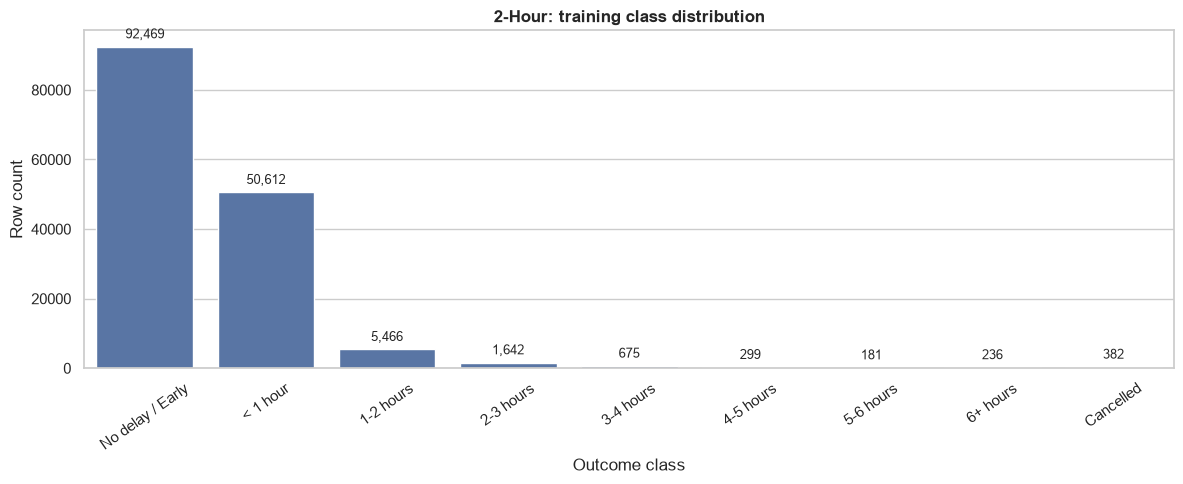

Encoded feature count: 173 | Train: (151962, 173) | Validation: (84932, 173) | Test: (99024, 173)


,split,accuracy,balanced_accuracy,macro_f1
0,Train,0.9559,0.9889,0.9809
1,Validation,0.6056,0.1330,0.1278
2,Test,0.6354,0.1353,0.1313


Train vs validation accuracy gap: 0.3504


,precision,recall,f1-score,support
No delay / Early,0.712,0.804,0.756,63389.000
< 1 hour,0.435,0.412,0.423,28909.000
1-2 hours,0.192,0.001,0.002,4042.000
2-3 hours,0.000,0.000,0.000,1350.000
3-4 hours,0.000,0.000,0.000,523.000
4-5 hours,0.000,0.000,0.000,246.000
5-6 hours,0.000,0.000,0.000,107.000
6+ hours,0.000,0.000,0.000,163.000
Cancelled,0.000,0.000,0.000,295.000
accuracy,0.635,0.635,0.635,0.635


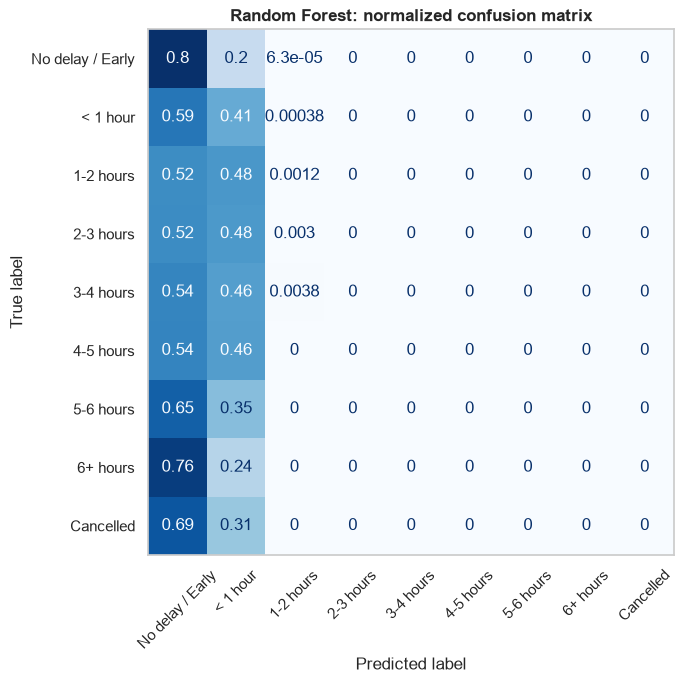

2-Hour: test accuracy = 0.6354, balanced accuracy = 0.1353, macro F1 = 0.1313.
This tree model improves raw accuracy, but its very large train/validation gap shows strong overfitting.


In [8]:
two_hour_rf_results = run_random_forest_model(
    csv_name="combined_data_2h.csv",
    horizon_name="2-Hour",
)

### 4-Hour Random Forest

4-Hour: loaded 339,996 rows from combined_data_4h.csv


,split,rows,share_of_rows,start_date,end_date
0,Train,154285,0.453785,2022-01-01,2023-12-31
1,Validation,86039,0.253059,2024-01-01,2024-12-31
2,Test,99672,0.293156,2025-01-01,2026-04-30


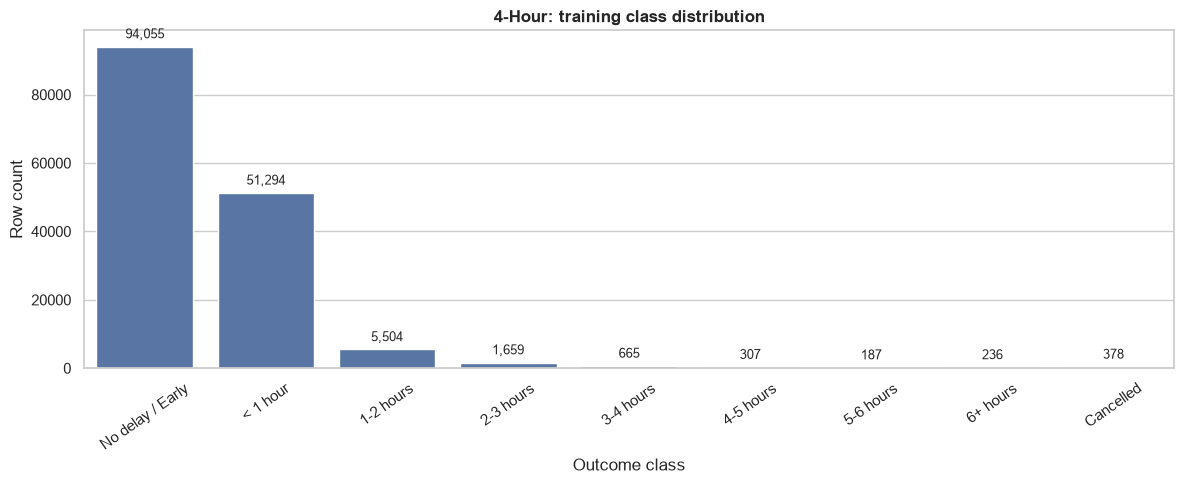

Encoded feature count: 173 | Train: (154285, 173) | Validation: (86039, 173) | Test: (99672, 173)


,split,accuracy,balanced_accuracy,macro_f1
0,Train,0.9526,0.9879,0.9802
1,Validation,0.6039,0.1319,0.1267
2,Test,0.6307,0.1343,0.1302


Train vs validation accuracy gap: 0.3487


,precision,recall,f1-score,support
No delay / Early,0.709,0.798,0.751,63797.000
< 1 hour,0.430,0.410,0.419,29166.000
1-2 hours,0.250,0.001,0.001,4006.000
2-3 hours,0.000,0.000,0.000,1354.000
3-4 hours,0.000,0.000,0.000,527.000
4-5 hours,0.000,0.000,0.000,251.000
5-6 hours,0.000,0.000,0.000,110.000
6+ hours,0.000,0.000,0.000,161.000
Cancelled,0.000,0.000,0.000,300.000
accuracy,0.631,0.631,0.631,0.631


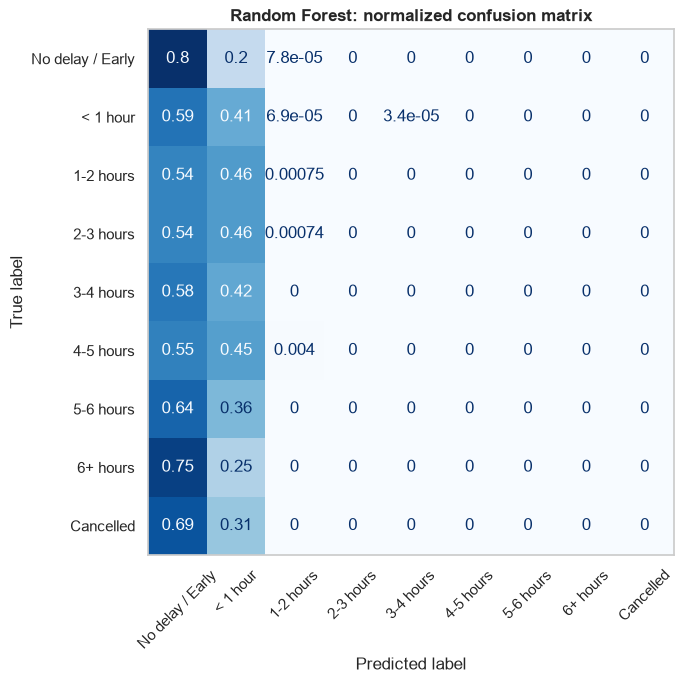

4-Hour: test accuracy = 0.6307, balanced accuracy = 0.1343, macro F1 = 0.1302.
This tree model improves raw accuracy, but its very large train/validation gap shows strong overfitting.


In [9]:
four_hour_rf_results = run_random_forest_model(
    csv_name="combined_data_4h.csv",
    horizon_name="4-Hour",
)

### Random Forest Comparison

,model,horizon,train_accuracy,validation_accuracy,test_accuracy,train_validation_gap,test_balanced_accuracy,test_macro_f1
0,Random Forest,2-Hour,0.9559,0.6056,0.6354,0.3504,0.1353,0.1313
1,Random Forest,4-Hour,0.9526,0.6039,0.6307,0.3487,0.1343,0.1302


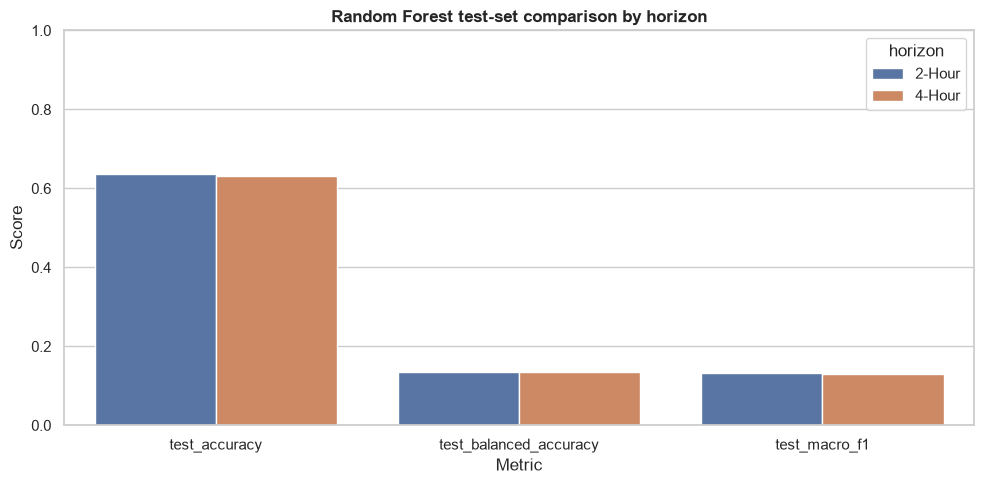

In [10]:
rf_comparison_df = pd.DataFrame(
    [
        two_hour_rf_results["summary_row"],
        four_hour_rf_results["summary_row"],
    ]
).round(4)

display(rf_comparison_df)

fig, ax = plt.subplots(figsize=(10, 5))
rf_plot_df = rf_comparison_df.melt(
    id_vars=["model", "horizon"],
    value_vars=["test_accuracy", "test_balanced_accuracy", "test_macro_f1"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=rf_plot_df, x="metric", y="score", hue="horizon", errorbar=None, ax=ax)
ax.set_title("Random Forest test-set comparison by horizon", fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

The thin vertical black lines that appeared on these Seaborn bar charts were the library's default uncertainty/error bars. Since each bar here is just one metric value, those lines were not meaningful, so the comparison charts below use `errorbar=None` to remove them.

### Neural Network Functions

In [11]:
def build_neural_network_model(num_features: int, num_classes: int) -> tf.keras.Model:
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)

    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(num_features,)),
            tf.keras.layers.Dense(
                128,
                activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            ),
            tf.keras.layers.Dropout(0.35),
            tf.keras.layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            ),
            tf.keras.layers.Dropout(0.35),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def run_neural_network_model(
    csv_name: str,
    horizon_name: str,
    epochs: int = 40,
    batch_size: int = 1024,
) -> dict[str, object]:
    df = load_horizon_dataset(csv_name)
    splits = temporal_split(df)

    display(build_split_summary(splits))
    plot_target_distribution(splits["Train"][TARGET], f"{horizon_name}: training class distribution")

    X_train = splits["Train"][FEATURE_COLUMNS]
    y_train = splits["Train"][TARGET]
    X_val = splits["Validation"][FEATURE_COLUMNS]
    y_val = splits["Validation"][TARGET]
    X_test = splits["Test"][FEATURE_COLUMNS]
    y_test = splits["Test"][TARGET]

    preprocessor = build_preprocessor()
    X_train_processed = preprocessor.fit_transform(X_train).astype("float32")
    X_val_processed = preprocessor.transform(X_val).astype("float32")
    X_test_processed = preprocessor.transform(X_test).astype("float32")

    print(
        f"Encoded feature count: {X_train_processed.shape[1]:,} | "
        f"Train: {X_train_processed.shape} | Validation: {X_val_processed.shape} | Test: {X_test_processed.shape}"
    )

    class_weights = compute_sqrt_class_weights(y_train)
    model = build_neural_network_model(
        num_features=X_train_processed.shape[1],
        num_classes=len(CLASS_ORDER),
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_processed,
        y_train.to_numpy(),
        validation_data=(X_val_processed, y_val.to_numpy()),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=0,
    )

    plot_training_history(history, f"{horizon_name}: Neural Network")

    train_predictions = np.argmax(model.predict(X_train_processed, batch_size=batch_size, verbose=0), axis=1)
    val_predictions = np.argmax(model.predict(X_val_processed, batch_size=batch_size, verbose=0), axis=1)
    test_predictions = np.argmax(model.predict(X_test_processed, batch_size=batch_size, verbose=0), axis=1)

    split_metrics = build_split_metrics_from_predictions(
        {
            "Train": (y_train.to_numpy(), train_predictions),
            "Validation": (y_val.to_numpy(), val_predictions),
            "Test": (y_test.to_numpy(), test_predictions),
        }
    )
    display(split_metrics.round(4))

    train_accuracy = split_metrics.loc[split_metrics["split"].eq("Train"), "accuracy"].iloc[0]
    validation_accuracy = split_metrics.loc[split_metrics["split"].eq("Validation"), "accuracy"].iloc[0]
    print(f"Train vs validation accuracy gap: {abs(train_accuracy - validation_accuracy):.4f}")

    report_df = classification_report_frame(y_test, test_predictions)
    display(report_df.round(3))
    plot_confusion(y_test, test_predictions, f"{horizon_name}: Neural Network confusion matrix")

    summary_row = summarize_results(horizon_name, "Neural Network", split_metrics)
    summary_row["epochs_trained"] = len(history.history["loss"])
    print(
        f"{horizon_name}: test accuracy = {summary_row['test_accuracy']:.4f}, "
        f"balanced accuracy = {summary_row['test_balanced_accuracy']:.4f}, "
        f"macro F1 = {summary_row['test_macro_f1']:.4f}."
    )

    return {
        "data": df,
        "split_metrics": split_metrics,
        "report": report_df,
        "summary_row": summary_row,
        "history": history,
    }

### 2-Hour Neural Network

,split,rows,share_of_rows,start_date,end_date
0,Train,151962,0.452378,2022-01-01,2023-12-31
1,Validation,84932,0.252836,2024-01-01,2024-12-31
2,Test,99024,0.294786,2025-01-01,2026-04-30


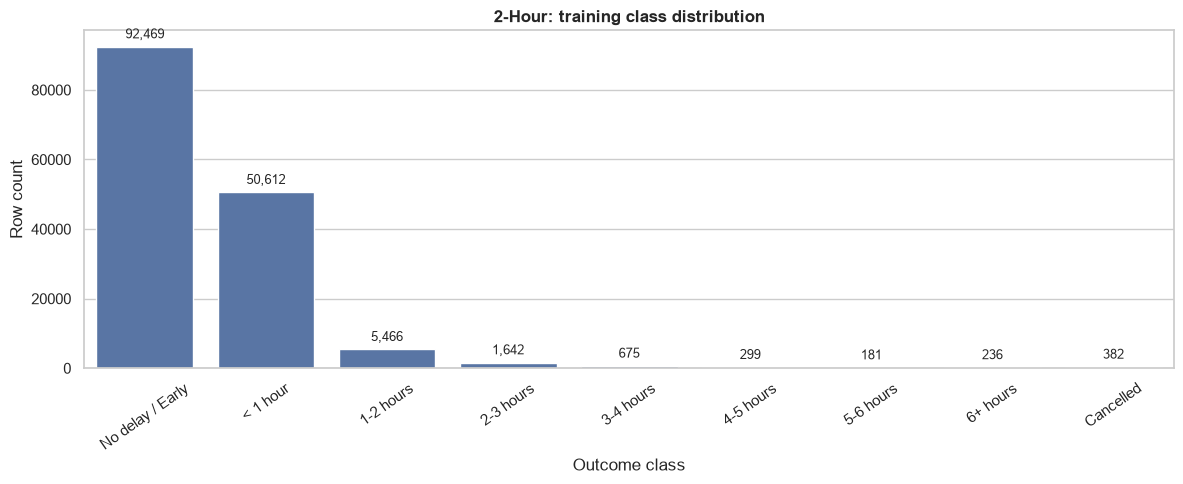

Encoded feature count: 173 | Train: (151962, 173) | Validation: (84932, 173) | Test: (99024, 173)



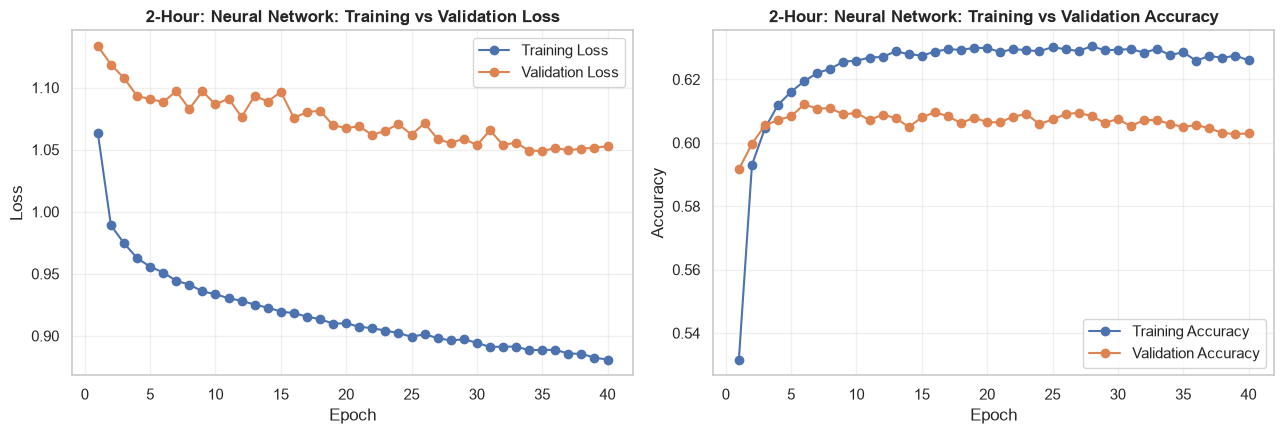

,split,accuracy,balanced_accuracy,macro_f1
0,Train,0.6469,0.1633,0.1708
1,Validation,0.6050,0.1362,0.1331
2,Test,0.6288,0.1326,0.1306


Train vs validation accuracy gap: 0.0419


,precision,recall,f1-score,support
No delay / Early,0.700,0.819,0.754,63389.000
< 1 hour,0.421,0.357,0.386,28909.000
1-2 hours,0.234,0.019,0.034,4042.000
2-3 hours,0.000,0.000,0.000,1350.000
3-4 hours,0.000,0.000,0.000,523.000
4-5 hours,0.000,0.000,0.000,246.000
5-6 hours,0.000,0.000,0.000,107.000
6+ hours,0.000,0.000,0.000,163.000
Cancelled,0.000,0.000,0.000,295.000
accuracy,0.629,0.629,0.629,0.629


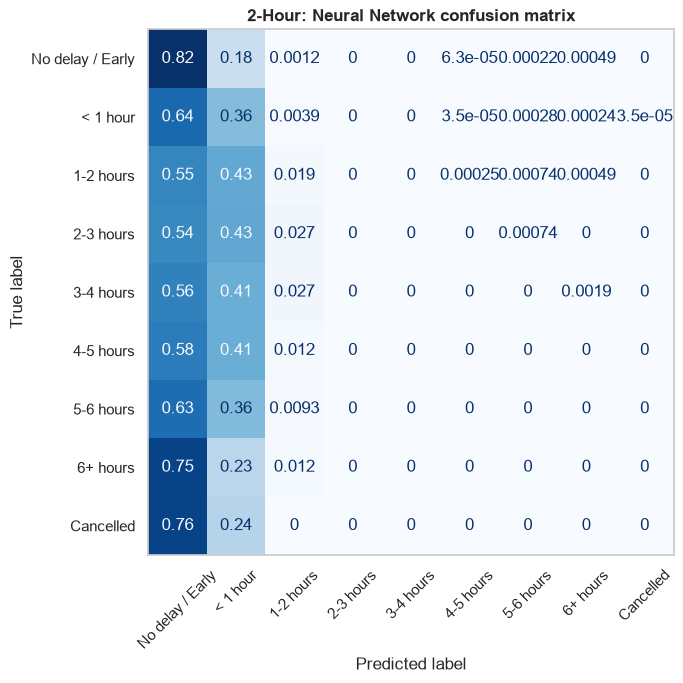

2-Hour: test accuracy = 0.6288, balanced accuracy = 0.1326, macro F1 = 0.1306.


In [12]:
two_hour_nn_results = run_neural_network_model(
    csv_name="combined_data_2h.csv",
    horizon_name="2-Hour",
    epochs=40,
    batch_size=1024,
)

### 4-Hour Neural Network

,split,rows,share_of_rows,start_date,end_date
0,Train,154285,0.453785,2022-01-01,2023-12-31
1,Validation,86039,0.253059,2024-01-01,2024-12-31
2,Test,99672,0.293156,2025-01-01,2026-04-30


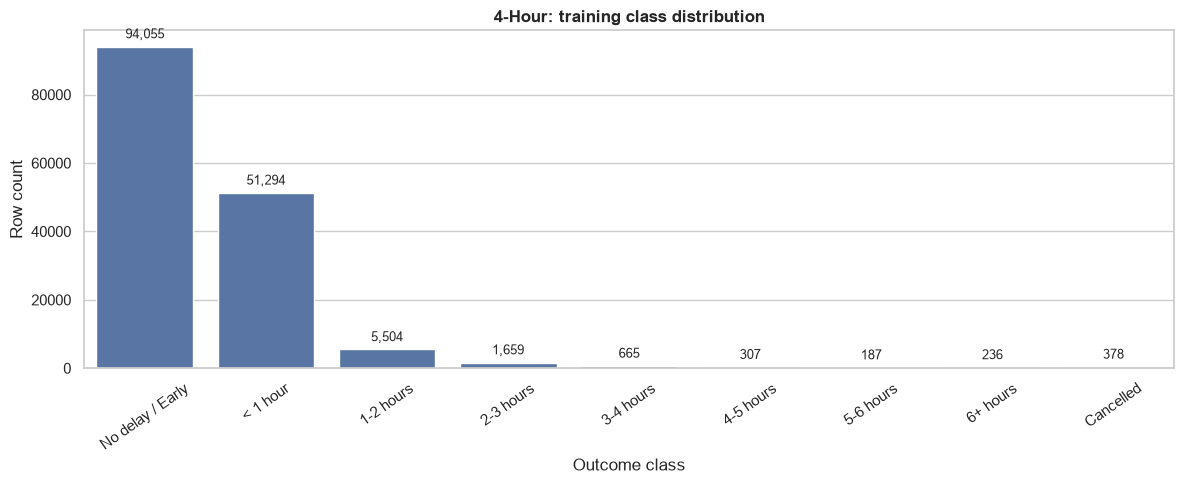

Encoded feature count: 173 | Train: (154285, 173) | Validation: (86039, 173) | Test: (99672, 173)


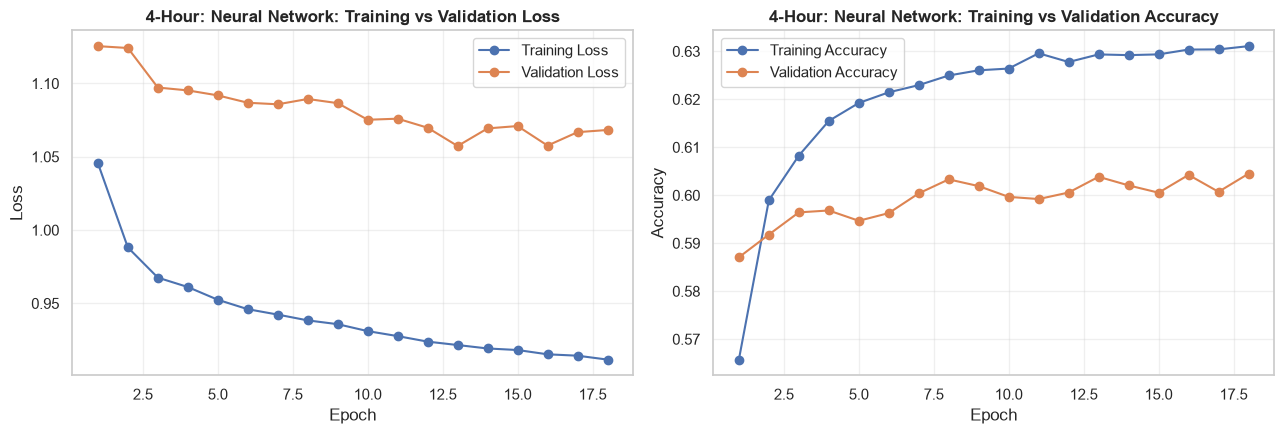

,split,accuracy,balanced_accuracy,macro_f1
0,Train,0.6427,0.1376,0.1343
1,Validation,0.6038,0.1335,0.1284
2,Test,0.6014,0.1327,0.1275


Train vs validation accuracy gap: 0.0389


,precision,recall,f1-score,support
No delay / Early,0.711,0.726,0.718,63797.000
< 1 hour,0.395,0.468,0.429,29166.000
1-2 hours,1.000,0.000,0.000,4006.000
2-3 hours,0.000,0.000,0.000,1354.000
3-4 hours,0.000,0.000,0.000,527.000
4-5 hours,0.000,0.000,0.000,251.000
5-6 hours,0.000,0.000,0.000,110.000
6+ hours,0.000,0.000,0.000,161.000
Cancelled,0.000,0.000,0.000,300.000
accuracy,0.601,0.601,0.601,0.601


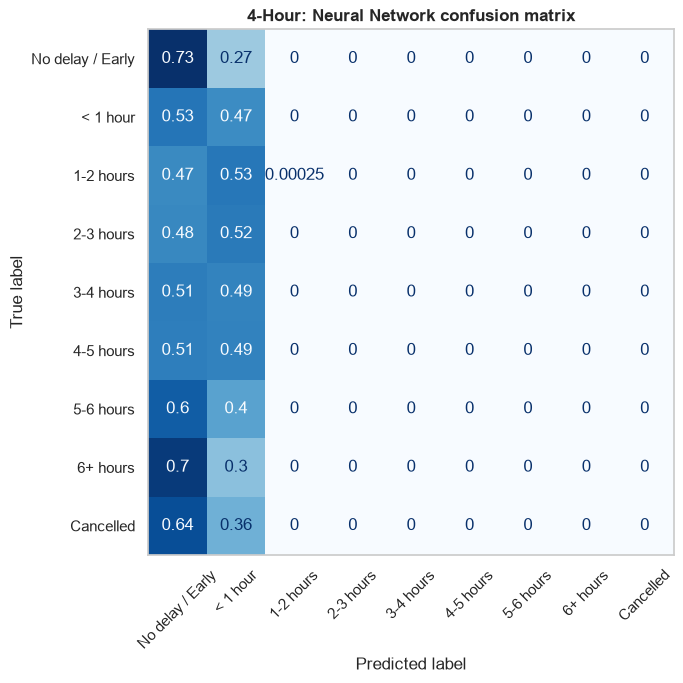

4-Hour: test accuracy = 0.6014, balanced accuracy = 0.1327, macro F1 = 0.1275.


In [13]:
four_hour_nn_results = run_neural_network_model(
    csv_name="combined_data_4h.csv",
    horizon_name="4-Hour",
    epochs=40,
    batch_size=1024,
)

The neural network usually has a much smaller train/validation gap because dropout, L2 regularization, and early stopping constrain overfitting.


### Random Forest vs Neural Network Comparison

,model,horizon,train_accuracy,validation_accuracy,test_accuracy,train_validation_gap,test_balanced_accuracy,test_macro_f1,epochs_trained
0,Random Forest,2-Hour,0.9559,0.6056,0.6354,0.3504,0.1353,0.1313,NaN
1,Random Forest,4-Hour,0.9526,0.6039,0.6307,0.3487,0.1343,0.1302,NaN
2,Neural Network,2-Hour,0.6469,0.6050,0.6288,0.0419,0.1326,0.1306,40.0
3,Neural Network,4-Hour,0.6427,0.6038,0.6014,0.0389,0.1327,0.1275,18.0


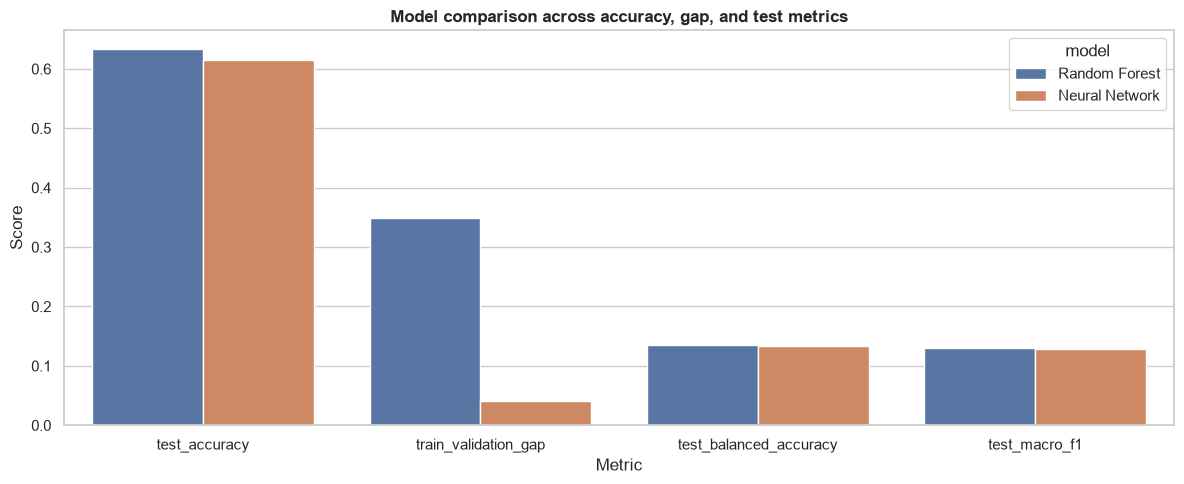

Smallest train/validation gap: Neural Network on 4-Hour (0.0389).
Highest test accuracy: Random Forest on 2-Hour (0.6354).


In [14]:
all_results_df = pd.DataFrame(
    [
        two_hour_rf_results["summary_row"],
        four_hour_rf_results["summary_row"],
        two_hour_nn_results["summary_row"],
        four_hour_nn_results["summary_row"],
    ]
).round(4)

display(all_results_df)

comparison_plot_df = all_results_df.melt(
    id_vars=["model", "horizon"],
    value_vars=["test_accuracy", "train_validation_gap", "test_balanced_accuracy", "test_macro_f1"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=comparison_plot_df, x="metric", y="score", hue="model", errorbar=None, ax=ax)
ax.set_title("Model comparison across accuracy, gap, and test metrics", fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

smallest_gap_row = all_results_df.sort_values("train_validation_gap").iloc[0]
best_accuracy_row = all_results_df.sort_values("test_accuracy", ascending=False).iloc[0]

print(
    f"Smallest train/validation gap: {smallest_gap_row['model']} on {smallest_gap_row['horizon']} "
    f"({smallest_gap_row['train_validation_gap']:.4f})."
)
print(
    f"Highest test accuracy: {best_accuracy_row['model']} on {best_accuracy_row['horizon']} "
    f"({best_accuracy_row['test_accuracy']:.4f})."
)

A smaller gap does not automatically mean the best final test score, so both generalization gap and test metrics should be reviewed together.